# Run all notebooks in the project

test with the new organization

In [46]:
#import library 
import pandas as pd

#read csv file
df = pd.read_csv(
"C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/data/REFLEXION.csv",
sep=","
)

#print results
print(df.head())
print(df.shape)

       sid  cisdrc  cinouv  cidiag  ciconsent  cisecu  ciage  cnitrbl  cniavc  \
0  C01P001       1       1       1          1       1      1        0       0   
1  C01P002       1       1       1          1       1      1        0       0   
2  C01P003       1       1       1          1       1      1        0       0   
3  C01P004       1       1       1          1       1      1        0       0   
4  C01P005       1       1       1          1       1      1        0       0   

   cnimoca  ...  v20_css9  v20_pgic  v20_eq_mob  v20_eq_auto  v20_eq_act  \
0        0  ...       1.0       3.0         1.0          1.0         2.0   
1        0  ...       1.0       3.0         1.0          2.0         2.0   
2        0  ...       1.0       3.0         1.0          1.0         2.0   
3        0  ...       NaN       NaN         NaN          NaN         NaN   
4        0  ...       1.0       3.0         1.0          1.0         2.0   

   v20_eq_doul  v20_eq_anx  v20_eq_sante  femotif       

In [47]:
#remove index line 3 and reset/reinitialize index
df = df.drop(df.index[3]).reset_index(drop=True)

# select columns with "css" 
df_css = df.filter(regex='css', axis=1)

# show first lines
print(df_css.head())

   icss_rea  icssdoul_s  icsshypall_s  icsshypallp_s  icsstemp_s  icsstempp_s  \
0         1         0.0           6.8            1.0        32.5          1.0   
1         1         0.0           4.3            0.0        25.2          0.0   
2         1         1.0           3.1            0.0        19.7          0.0   
3         1         0.5           5.0            0.0        28.1          0.0   
4         1         0.0           3.6            1.0        30.1          1.0   

   icsssud_s  icssoed_s  icssoedp_s  icssforce1_s  ...  v20_cssforcescref  \
0       40.0       35.5         1.0          20.1  ...                7.5   
1       39.0       38.9         0.0          23.6  ...               25.2   
2       37.0       45.7         0.0          43.1  ...               44.8   
3       28.0       41.3         0.0          30.0  ...               27.6   
4       38.0       38.1         1.0          26.0  ...               25.3   

   v20_css1  v20_css2  v20_css3  v20_css4  v20_css

In [48]:
# Remove columns with "rea" and columns finish by "css1"
df_css_clean = df_css.filter(regex='^(?!.*rea)(?!.*css1$)', axis=1)


# Keep columns that start with "v"              
df_v = df_css_clean.filter(regex='^v', axis=1)

# Remove columns "v" with cssforce1, cssforce2, cssforce3 or cssforcescref
df_v = df_v.filter(regex='^(?!.*cssforce([123]|scref)).*', axis=1)

# Keep 3 columns "icsstemp_s", "icsssud_s", "icssforcemoy_s"
df_exceptions = df_css_clean.filter(items=["icsstemp_s", "icsssud_s", "icssforcemoy_s"])

# Combine
df_css_clean = pd.concat([df_v, df_exceptions], axis=1)

#see results
print(df_css_clean.shape)
print(df_css_clean.columns)
print(df_css_clean.head())



(6, 323)
Index(['v1_cssdoul', 'v1_csshypall', 'v1_csstemp', 'v1_csseryth', 'v1_csssud',
       'v1_cssoed', 'v1_csstroph', 'v1_cssforcemoy', 'v1_css2', 'v1_css3',
       ...
       'v20_css3', 'v20_css4', 'v20_css5', 'v20_css6', 'v20_css7', 'v20_css8',
       'v20_css9', 'icsstemp_s', 'icsssud_s', 'icssforcemoy_s'],
      dtype='object', length=323)
   v1_cssdoul  v1_csshypall  v1_csstemp  v1_csseryth  v1_csssud  v1_cssoed  \
0         7.3           1.0         0.0          1.0       34.0        0.0   
1         9.8           1.0         1.0          1.0       47.8        1.0   
2         2.0           1.0         0.0          0.0       46.5        1.0   
3         7.5           1.0         1.0          1.0       59.6        0.0   
4         3.5           1.0         0.0          1.0       28.9        0.0   

   v1_csstroph  v1_cssforcemoy  v1_css2  v1_css3  ...  v20_css3  v20_css4  \
0          0.0             4.9      1.0      1.0  ...       1.0       1.0   
1          0.0           

In [49]:
#see clean table
df_css_clean

,v1_cssdoul,v1_csshypall,v1_csstemp,v1_csseryth,v1_csssud,v1_cssoed,v1_csstroph,v1_cssforcemoy,v1_css2,v1_css3,...,v20_css3,v20_css4,v20_css5,v20_css6,v20_css7,v20_css8,v20_css9,icsstemp_s,icsssud_s,icssforcemoy_s
0,7.3,1.0,0.0,1.0,34.0,0.0,0.0,4.9,1.0,1.0,...,1.0,1.0,0.0,1.0,1.0,0.0,1.0,32.5,40.0,20.5
1,9.8,1.0,1.0,1.0,47.8,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,25.2,39.0,25.2
2,2.0,1.0,0.0,0.0,46.5,1.0,0.0,13.3,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,19.7,37.0,44.8
3,7.5,1.0,1.0,1.0,59.6,0.0,0.0,22.7,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,28.1,28.0,27.7
4,3.5,1.0,0.0,1.0,28.9,0.0,1.0,5.9,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,30.1,38.0,25.6
5,7.0,0.0,0.0,1.0,35.2,0.0,1.0,8.3,1.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,31.3,34.0,17.0


In [50]:
# New DataFrame for binarization
binarization = df_css_clean.copy()

# Select columns with "cssdoul"
cols_cssdoul = binarization.filter(regex='cssdoul', axis=1).columns

# Apply binary transformation: >=8 -> 1, <8 -> 0
binarization[cols_cssdoul] = binarization[cols_cssdoul].applymap(
    lambda x: 1 if x >= 8 else (0 if pd.notna(x) else pd.NA)
)

# Preview
print("Columns transformed to binary:", list(cols_cssdoul))
print(binarization[cols_cssdoul].head())

Columns transformed to binary: ['v1_cssdoul', 'v2_cssdoul', 'v3_cssdoul', 'v4_cssdoul', 'v5_cssdoul', 'v6_cssdoul', 'v7_cssdoul', 'v8_cssdoul', 'v9_cssdoul', 'v10_cssdoul', 'v11_cssdoul', 'v12_cssdoul', 'v13_cssdoul', 'v14_cssdoul', 'v15_cssdoul', 'v16_cssdoul', 'v17_cssdoul', 'v18_cssdoul', 'v19_cssdoul', 'v20_cssdoul']
   v1_cssdoul v2_cssdoul v3_cssdoul  v4_cssdoul  v5_cssdoul  v6_cssdoul  \
0           0          0          0           0           0           0   
1           1          1       <NA>           1           1           1   
2           0          0          0           0           0           0   
3           0       <NA>          1           1           0           0   
4           0          0          0           0           0           0   

  v7_cssdoul  v8_cssdoul  v9_cssdoul  v10_cssdoul  v11_cssdoul v12_cssdoul  \
0          0           0           0            0            0           0   
1          1           1           1            1            1        

C:\Users\Anaëlle\AppData\Local\Temp\ipykernel_9920\563250461.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binarization[cols_cssdoul] = binarization[cols_cssdoul].applymap(


In [51]:
# csstemp columns are already binarized
cols_csstemp = df_css_clean.filter(regex='csstemp', axis=1).columns

# Preview column names
print(list(cols_csstemp))

# View first five rows of csstemp columns
print(df_css_clean[cols_csstemp].head())

['v1_csstemp', 'v2_csstemp', 'v3_csstemp', 'v4_csstemp', 'v5_csstemp', 'v6_csstemp', 'v7_csstemp', 'v8_csstemp', 'v9_csstemp', 'v10_csstemp', 'v11_csstemp', 'v12_csstemp', 'v13_csstemp', 'v14_csstemp', 'v15_csstemp', 'v16_csstemp', 'v17_csstemp', 'v18_csstemp', 'v19_csstemp', 'v20_csstemp', 'icsstemp_s']
   v1_csstemp  v2_csstemp  v3_csstemp  v4_csstemp  v5_csstemp  v6_csstemp  \
0         0.0         0.0         1.0         1.0         0.0         1.0   
1         1.0         1.0         NaN         0.0         1.0         0.0   
2         0.0         1.0         1.0         1.0         1.0         1.0   
3         1.0         NaN         1.0         1.0         0.0         1.0   
4         0.0         1.0         1.0         1.0         0.0         0.0   

   v7_csstemp  v8_csstemp  v9_csstemp  v10_csstemp  ...  v12_csstemp  \
0         1.0         1.0         1.0          1.0  ...          1.0   
1         0.0         1.0         0.0          1.0  ...          1.0   
2         1.0  

In [52]:
# Select columns with "csssud" to check values
cols_csssud = df_css_clean.filter(regex='csssud', axis=1).columns

# Preview column names
print("csssud columns:", list(cols_csssud))

# View first five rows of csssud columns
print(df_css_clean[cols_csssud].head())

csssud columns: ['v1_csssud', 'v2_csssud', 'v3_csssud', 'v4_csssud', 'v5_csssud', 'v6_csssud', 'v7_csssud', 'v8_csssud', 'v9_csssud', 'v10_csssud', 'v11_csssud', 'v12_csssud', 'v13_csssud', 'v14_csssud', 'v15_csssud', 'v16_csssud', 'v17_csssud', 'v18_csssud', 'v19_csssud', 'v20_csssud', 'icsssud_s']
   v1_csssud  v2_csssud  v3_csssud  v4_csssud  v5_csssud  v6_csssud  \
0       34.0       36.7       45.3       40.0       48.7       46.3   
1       47.8       43.5        NaN       42.5       44.3       45.5   
2       46.5       44.4       37.1       40.3       36.7       38.3   
3       59.6        NaN       46.7       38.8       57.7       55.7   
4       28.9       37.8       41.3       39.9       37.6       52.0   

   v7_csssud  v8_csssud  v9_csssud  v10_csssud  ...  v12_csssud  v13_csssud  \
0       48.6       32.4       41.0        42.3  ...        41.8        43.8   
1       39.4       42.4       40.1        38.1  ...        34.5        40.7   
2       43.0       41.7       39.7 

In [53]:
# Check data for "cssoed" (already binarized)

# Columns with cssoed
cols_cssoed = df_css_clean.filter(regex='cssoed', axis=1).columns
print("cssoed columns:", list(cols_cssoed))

# View results
print("\nPreview of cssoed columns:")
print(df_css_clean[cols_cssoed].head())

cssoed columns: ['v1_cssoed', 'v2_cssoed', 'v3_cssoed', 'v4_cssoed', 'v5_cssoed', 'v6_cssoed', 'v7_cssoed', 'v8_cssoed', 'v9_cssoed', 'v10_cssoed', 'v11_cssoed', 'v12_cssoed', 'v13_cssoed', 'v14_cssoed', 'v15_cssoed', 'v16_cssoed', 'v17_cssoed', 'v18_cssoed', 'v19_cssoed', 'v20_cssoed']

Preview of cssoed columns:
   v1_cssoed  v2_cssoed  v3_cssoed  v4_cssoed  v5_cssoed  v6_cssoed  \
0        0.0        1.0        1.0        0.0        1.0        1.0   
1        1.0        1.0        NaN        1.0        1.0        1.0   
2        1.0        1.0        0.0        1.0        0.0        1.0   
3        0.0        NaN        1.0        0.0        1.0        1.0   
4        0.0        1.0        0.0        1.0        1.0        1.0   

   v7_cssoed  v8_cssoed  v9_cssoed  v10_cssoed  v11_cssoed  v12_cssoed  \
0        1.0        0.0        1.0         1.0         1.0         0.0   
1        1.0        1.0        1.0         1.0         1.0         1.0   
2        1.0        0.0        1.0 

In [54]:
# Check data for "forcemoy"

# Columns with "cssforcemoy"
cols_cssforcemoy = df_css_clean.filter(regex='cssforcemoy', axis=1).columns
print("cssforcemoy columns:", list(cols_cssforcemoy))

# View results
print("\nPreview of cssforcemoy columns:")
print(df_css_clean[cols_cssforcemoy].head())

cssforcemoy columns: ['v1_cssforcemoy', 'v2_cssforcemoy', 'v3_cssforcemoy', 'v4_cssforcemoy', 'v5_cssforcemoy', 'v6_cssforcemoy', 'v7_cssforcemoy', 'v8_cssforcemoy', 'v9_cssforcemoy', 'v10_cssforcemoy', 'v11_cssforcemoy', 'v12_cssforcemoy', 'v13_cssforcemoy', 'v14_cssforcemoy', 'v15_cssforcemoy', 'v16_cssforcemoy', 'v17_cssforcemoy', 'v18_cssforcemoy', 'v19_cssforcemoy', 'v20_cssforcemoy', 'icssforcemoy_s']

Preview of cssforcemoy columns:
   v1_cssforcemoy  v2_cssforcemoy  v3_cssforcemoy  v4_cssforcemoy  \
0             4.9             4.9             3.0             5.1   
1             0.0             0.0             NaN             0.0   
2            13.3            16.8            16.3            13.3   
3            22.7             NaN            18.8            18.9   
4             5.9             6.8             7.7             7.4   

   v5_cssforcemoy  v6_cssforcemoy  v7_cssforcemoy  v8_cssforcemoy  \
0             4.6             5.4             8.2             7.6   
1  

In [55]:
# Binarization of "sudation"
# Pathologic columns "csssud" with 30% difference
cols_csssud = df_css_clean.filter(regex='^v.*_csssud$', axis=1).columns

# Binarization
binarization_sud = ((df_css_clean[cols_csssud].sub(df_css_clean['icsssud_s'], axis=0)
                     .abs()
                     .div(df_css_clean['icsssud_s'], axis=0)) >= 0.3)

binarization_sud = binarization_sud.where(df_css_clean[cols_csssud].notna()).astype("Int64")

# View first rows
print(binarization_sud.head())


# Binarization of "force moyenne"
# Pathologic columns "forcemoy"
cols_cssforcemoy = df_css_clean.filter(regex='^v.*_cssforcemoy$', axis=1).columns

# Binarization with 5kg difference
binarization_forcemoy = ((df_css_clean[cols_cssforcemoy]
                          .sub(df_css_clean['icssforcemoy_s'], axis=0)
                          .abs()) >= 5)

binarization_forcemoy = binarization_forcemoy.where(df_css_clean[cols_cssforcemoy].notna()).astype("Int64")

# View first rows
print(binarization_forcemoy.head())

   v1_csssud  v2_csssud  v3_csssud  v4_csssud  v5_csssud  v6_csssud  \
0          0          0          0          0          0          0   
1          0          0       <NA>          0          0          0   
2          0          0          0          0          0          0   
3          1       <NA>          1          1          1          1   
4          0          0          0          0          0          1   

   v7_csssud  v8_csssud  v9_csssud  v10_csssud  v11_csssud  v12_csssud  \
0          0          0          0           0           0           0   
1          0          0          0           0           0           0   
2          0          0          0           0           0           0   
3       <NA>          1          1           1           0        <NA>   
4          0          0          0           1           0           0   

   v13_csssud  v14_csssud  v15_csssud  v16_csssud  v17_csssud  v18_csssud  \
0           0        <NA>           0           0  

In [56]:
# Final table based on df_css_clean
df_binarized_final = df_css_clean.copy()

# Replace pain columns with binary version
df_binarized_final[cols_cssdoul] = binarization[cols_cssdoul]

# Replace "sudation" columns with binary version
df_binarized_final[cols_csssud] = binarization_sud

# Replace "forcemoy" columns with binary version
df_binarized_final[cols_cssforcemoy] = binarization_forcemoy

# Drop healthy columns
df_binarized_final = df_binarized_final.drop(
    columns=["icsssud_s", "icssforcemoy_s", "icsstemp_s"],
    errors="ignore"
)

# View cleaned DataFrame
df_binarized_final


,v1_cssdoul,v1_csshypall,v1_csstemp,v1_csseryth,v1_csssud,v1_cssoed,v1_csstroph,v1_cssforcemoy,v1_css2,v1_css3,...,v20_csstroph,v20_cssforcemoy,v20_css2,v20_css3,v20_css4,v20_css5,v20_css6,v20_css7,v20_css8,v20_css9
0,0,1.0,0.0,1.0,0,0.0,0.0,1,1.0,1.0,...,1.0,1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
1,1,1.0,1.0,1.0,0,1.0,0.0,1,1.0,1.0,...,0.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0,1.0,0.0,0.0,0,1.0,0.0,1,0.0,0.0,...,0.0,1,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,0,1.0,1.0,1.0,1,0.0,0.0,1,1.0,1.0,...,1.0,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0,1.0,0.0,1.0,0,0.0,1.0,1,1.0,1.0,...,1.0,1,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
5,0,0.0,0.0,1.0,0,0.0,1.0,1,1.0,1.0,...,0.0,1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0


In [57]:

#define index
df_binarise_final.index = [f"case {i+1}" for i in range(len(df_binarise_final))]

# name the index
df_binarise_final.index.name = "sid"

#export to csv

df_binarise_final.to_csv(
"C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/data/df_binarise_final.csv",
sep=";",
encoding="utf-8-sig",
index=True
)

In [58]:
#open csv file df_binarise_final to check lines
df = pd.read_csv(
    "C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/data/df_binarise_final.csv",
    sep=';' 
)
#print results
print(df.head())
print(df.shape) 

      sid  v1_cssdoul  v1_csshypall  v1_csstemp  v1_csseryth  v1_csssud  \
0  case 1           0           1.0         0.0          1.0          0   
1  case 2           1           1.0         1.0          1.0          0   
2  case 3           0           1.0         0.0          0.0          0   
3  case 4           0           1.0         1.0          1.0          1   
4  case 5           0           1.0         0.0          1.0          0   

   v1_cssoed  v1_csstroph  v1_cssforcemoy  v1_css2  ...  v20_csstroph  \
0        0.0          0.0               1      1.0  ...           1.0   
1        1.0          0.0               1      1.0  ...           0.0   
2        1.0          0.0               1      0.0  ...           0.0   
3        0.0          0.0               1      1.0  ...           1.0   
4        0.0          1.0               1      1.0  ...           1.0   

   v20_cssforcemoy  v20_css2  v20_css3  v20_css4  v20_css5  v20_css6  \
0                1       1.0       1.0

In [59]:
# Create table for Bland-Altman analysis
# Copy binarized DataFrame
df_score = df_binarized_final.copy()

# New table for scores
df_scores = pd.DataFrame(index=df_binarized_final.index)

# Loop over visits V1 to V20
for i in range(1, 21):

    # Visit columns
    cols_v = df_binarized_final.filter(regex=f'^v{i}_').columns

    # Separate objective / subjective columns
    cols_obj = cols_v[:8]   # first 8 columns
    cols_subj = cols_v[8:]  # last 8 columns

    # Calculate scores
    df_scores[f'V{i}_Scoreobj'] = df_binarized_final[cols_obj].sum(axis=1)
    df_scores[f'V{i}_Scoresubj'] = df_binarized_final[cols_subj].sum(axis=1)

# Final result
print(df_scores.shape)
print(df_scores.head())

# Export scores to CSV
df_scores.to_csv(
    "C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/data/df_scores_final.csv",
    sep=";",
    encoding="utf-8-sig",
    index=True
)


(6, 40)
   V1_Scoreobj  V1_Scoresubj V2_Scoreobj  V2_Scoresubj V3_Scoreobj  \
0          3.0           7.0         4.0           7.0         5.0   
1          6.0           8.0         6.0           8.0           0   
2          3.0           5.0         3.0           6.0         3.0   
3          5.0           6.0           0           0.0         7.0   
4          4.0           6.0         6.0           7.0         4.0   

   V3_Scoresubj  V4_Scoreobj  V4_Scoresubj  V5_Scoreobj  V5_Scoresubj  ...  \
0           7.0          5.0           7.0          4.0           7.0  ...   
1           0.0          6.0           8.0          6.0           8.0  ...   
2           6.0          4.0           6.0          2.0           5.0  ...   
3           5.0          6.0           4.0          5.0           4.0  ...   
4           7.0          5.0           7.0          5.0           7.0  ...   

   V16_Scoreobj  V16_Scoresubj V17_Scoreobj  V17_Scoresubj  V18_Scoreobj  \
0           6.0           

       V1_Scoreobj  V1_Scoresubj  V2_Scoresubj  V3_Scoresubj  V4_Scoreobj  \
count          6.0      6.000000      6.000000      6.000000          6.0   
mean           4.0      6.500000      5.666667      5.333333     4.666667   
std       1.264911      1.048809      2.875181      2.732520     1.505545   
min            3.0      5.000000      0.000000      0.000000          2.0   
25%            3.0      6.000000      6.000000      5.250000         4.25   
50%            3.5      6.500000      6.500000      6.500000          5.0   
75%           4.75      7.000000      7.000000      7.000000         5.75   
max            6.0      8.000000      8.000000      7.000000          6.0   

       V4_Scoresubj  V5_Scoreobj  V5_Scoresubj  V6_Scoreobj  V6_Scoresubj  \
count      6.000000          6.0      6.000000          6.0      6.000000   
mean       6.500000     3.666667      6.333333     4.666667      6.166667   
std        1.378405     2.250926      1.505545     1.861899      1.329160  

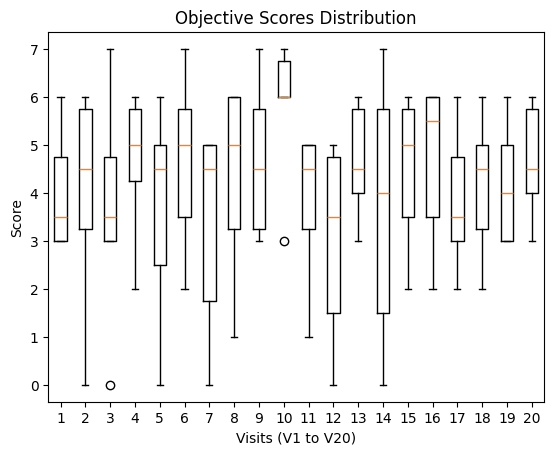

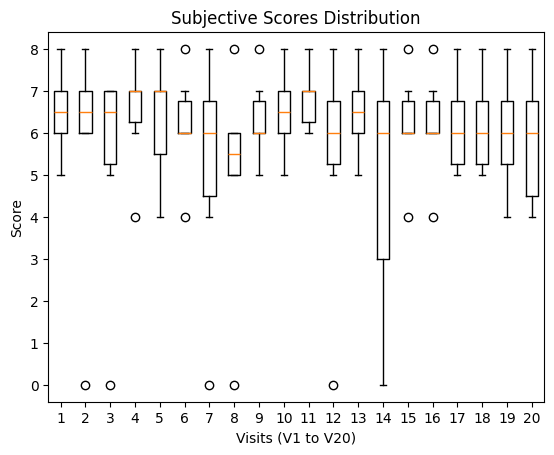

In [60]:
#descriptives statistics
df_scores.describe()

print(df_scores.describe())

import matplotlib.pyplot as plt

# Colonnes objectives et subjectives
cols_obj = [col for col in df_scores.columns if "Scoreobj" in col]
cols_subj = [col for col in df_scores.columns if "Scoresubj" in col]

# Boxplot objectifs
plt.figure()
plt.boxplot(df_scores[cols_obj].values)
plt.title("Objective Scores Distribution")
plt.xlabel("Visits (V1 to V20)")
plt.ylabel("Score")
plt.show()

# Boxplot subjectifs
plt.figure()
plt.boxplot(df_scores[cols_subj].values)
plt.title("Subjective Scores Distribution")
plt.xlabel("Visits (V1 to V20)")
plt.ylabel("Score")
plt.show()


In [61]:
# -------------------
# Exporter tout votre code Python en HTML
# -------------------

from datetime import datetime

# Votre code complet (copiez-collez tout ici)
code_complet = """
# Run all notebooks in the project
test with the new organization
#import library 
import pandas as pd

#read csv file
df = pd.read_csv(
"C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/data/REFLEXION.csv",
sep=","
)

#print results
print(df.head())
print(df.shape)
#remove index line 3 and reset/reinitialize index
df = df.drop(df.index[3]).reset_index(drop=True)

# select columns with "css" 
df_css = df.filter(regex='css', axis=1)

# show first lines
print(df_css.head())
# Remove columns with "rea" and columns finish by "css1"
df_css_clean = df_css.filter(regex='^(?!.*rea)(?!.*css1$)', axis=1)


# Keep columns that start with "v"              
df_v = df_css_clean.filter(regex='^v', axis=1)

# Remove columns "v" with cssforce1, cssforce2, cssforce3 or cssforcescref
df_v = df_v.filter(regex='^(?!.*cssforce([123]|scref)).*', axis=1)

# Keep 3 columns "icsstemp_s", "icsssud_s", "icssforcemoy_s"
df_exceptions = df_css_clean.filter(items=["icsstemp_s", "icsssud_s", "icssforcemoy_s"])

# Combine
df_css_clean = pd.concat([df_v, df_exceptions], axis=1)

#see results
print(df_css_clean.shape)
print(df_css_clean.columns)
print(df_css_clean.head())


#see clean table
df_css_clean
# New DataFrame for binarization
binarization = df_css_clean.copy()

# Select columns with "cssdoul"
cols_cssdoul = binarization.filter(regex='cssdoul', axis=1).columns

# Apply binary transformation: >=8 -> 1, <8 -> 0
binarization[cols_cssdoul] = binarization[cols_cssdoul].applymap(
    lambda x: 1 if x >= 8 else (0 if pd.notna(x) else pd.NA)
)

# Preview
print("Columns transformed to binary:", list(cols_cssdoul))
print(binarization[cols_cssdoul].head())
# csstemp columns are already binarized
cols_csstemp = df_css_clean.filter(regex='csstemp', axis=1).columns

# Preview column names
print(list(cols_csstemp))

# View first five rows of csstemp columns
print(df_css_clean[cols_csstemp].head())
# Select columns with "csssud" to check values
cols_csssud = df_css_clean.filter(regex='csssud', axis=1).columns

# Preview column names
print("csssud columns:", list(cols_csssud))

# View first five rows of csssud columns
print(df_css_clean[cols_csssud].head())
# Check data for "cssoed" (already binarized)

# Columns with cssoed
cols_cssoed = df_css_clean.filter(regex='cssoed', axis=1).columns
print("cssoed columns:", list(cols_cssoed))

# View results
print("\nPreview of cssoed columns:")
print(df_css_clean[cols_cssoed].head())
# Check data for "forcemoy"

# Columns with "cssforcemoy"
cols_cssforcemoy = df_css_clean.filter(regex='cssforcemoy', axis=1).columns
print("cssforcemoy columns:", list(cols_cssforcemoy))

# View results
print("\nPreview of cssforcemoy columns:")
print(df_css_clean[cols_cssforcemoy].head())
# Binarization of "sudation"
# Pathologic columns "csssud" with 30% difference
cols_csssud = df_css_clean.filter(regex='^v.*_csssud$', axis=1).columns

# Binarization
binarization_sud = ((df_css_clean[cols_csssud].sub(df_css_clean['icsssud_s'], axis=0)
                     .abs()
                     .div(df_css_clean['icsssud_s'], axis=0)) >= 0.3)

binarization_sud = binarization_sud.where(df_css_clean[cols_csssud].notna()).astype("Int64")

# View first rows
print(binarization_sud.head())


# Binarization of "force moyenne"
# Pathologic columns "forcemoy"
cols_cssforcemoy = df_css_clean.filter(regex='^v.*_cssforcemoy$', axis=1).columns

# Binarization with 5kg difference
binarization_forcemoy = ((df_css_clean[cols_cssforcemoy]
                          .sub(df_css_clean['icssforcemoy_s'], axis=0)
                          .abs()) >= 5)

binarization_forcemoy = binarization_forcemoy.where(df_css_clean[cols_cssforcemoy].notna()).astype("Int64")

# View first rows
print(binarization_forcemoy.head())
# Final table based on df_css_clean
df_binarized_final = df_css_clean.copy()

# Replace pain columns with binary version
df_binarized_final[cols_cssdoul] = binarization[cols_cssdoul]

# Replace "sudation" columns with binary version
df_binarized_final[cols_csssud] = binarization_sud

# Replace "forcemoy" columns with binary version
df_binarized_final[cols_cssforcemoy] = binarization_forcemoy

# Drop healthy columns
df_binarized_final = df_binarized_final.drop(
    columns=["icsssud_s", "icssforcemoy_s", "icsstemp_s"],
    errors="ignore"
)

# View cleaned DataFrame
df_binarized_final


#define index
df_binarise_final.index = [f"case {i+1}" for i in range(len(df_binarise_final))]

# name the index
df_binarise_final.index.name = "sid"

#export to csv

df_binarise_final.to_csv(
"C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/data/df_binarise_final.csv",
sep=";",
encoding="utf-8-sig",
index=True
)
#open csv file df_binarise_final to check lines
df = pd.read_csv(
    "C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/data/df_binarise_final.csv",
    sep=';' 
)
#print results
print(df.head())
print(df.shape) 
# Create table for Bland-Altman analysis
# Copy binarized DataFrame
df_score = df_binarized_final.copy()

# New table for scores
df_scores = pd.DataFrame(index=df_binarized_final.index)

# Loop over visits V1 to V20
for i in range(1, 21):

    # Visit columns
    cols_v = df_binarized_final.filter(regex=f'^v{i}_').columns

    # Separate objective / subjective columns
    cols_obj = cols_v[:8]   # first 8 columns
    cols_subj = cols_v[8:]  # last 8 columns

    # Calculate scores
    df_scores[f'V{i}_Scoreobj'] = df_binarized_final[cols_obj].sum(axis=1)
    df_scores[f'V{i}_Scoresubj'] = df_binarized_final[cols_subj].sum(axis=1)

# Final result
print(df_scores.shape)
print(df_scores.head())

# Export scores to CSV
df_scores.to_csv(
    "C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/data/df_scores_final.csv",
    sep=";",
    encoding="utf-8-sig",
    index=True
)

#descriptives statistics
df_scores.describe()

print(df_scores.describe())

import matplotlib.pyplot as plt

# Colonnes objectives et subjectives
cols_obj = [col for col in df_scores.columns if "Scoreobj" in col]
cols_subj = [col for col in df_scores.columns if "Scoresubj" in col]

# Boxplot objectifs
plt.figure()
plt.boxplot(df_scores[cols_obj].values)
plt.title("Objective Scores Distribution")
plt.xlabel("Visits (V1 to V20)")
plt.ylabel("Score")
plt.show()

# Boxplot subjectifs
plt.figure()
plt.boxplot(df_scores[cols_subj].values)
plt.title("Subjective Scores Distribution")
plt.xlabel("Visits (V1 to V20)")
plt.ylabel("Score")
plt.show()
"""

# Générer la date du jour automatiquement
date_du_jour = datetime.now().strftime("%d/%m/%Y")

# Nouveau chemin avec le bon nom de fichier
html_file = "C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/akakpovi.anaelle.html"

# Générer le HTML
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Code for Python Soutenance</title>
<style>
body {{ font-family: monospace; background-color:#f5f5f5; padding:20px; }}
h1 {{ text-align: center; }}
h3 {{ text-align: center; font-weight: normal; }}
pre {{ background-color:#eee; padding:15px; border-radius:5px; overflow-x:auto; }}
</style>
</head>
<body>

<h1>Code for Python Soutenance</h1>
<h3>{date_du_jour}</h3>
<h3>by Anaëlle AKAKPOVI</h3>

<pre>{code_complet}</pre>

</body>
</html>
"""

# Sauvegarder
with open(html_file, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"✅ HTML généré : {html_file}")

✅ HTML généré : C:/Users/Anaëlle/Desktop/Stage CHU/AKAKPOVI.ANAELLE/Soutenance_Python/akakpovi.anaelle.html
